# EconML Tutorial 09: Inference, Intervals, And Uncertainty

This notebook is about the part of causal machine learning that often gets skipped when people are excited about heterogeneous treatment effects: **how sure are we?**

A CATE model can produce a treatment-effect estimate for every user, customer, product, region, or session. That is powerful, but it also creates a dangerous temptation: sort everyone by the point estimate and treat the top group. In real decision systems, point estimates are noisy. Some units look high-benefit because the model has strong signal. Others look high-benefit because they live in sparse parts of the data where the estimator is uncertain.

EconML includes estimators that can return treatment-effect intervals. Those intervals do not prove the causal design is correct, but they help answer practical questions:

- Is the average treatment effect clearly different from zero?
- Are the highest predicted CATEs also precise enough to act on?
- Which segments have wide intervals because overlap is weak or data are sparse?
- How much does a policy change when we rank by a lower confidence bound instead of a raw point estimate?
- What should we report so a reader can distinguish signal from model noise?

We use synthetic data with known ground-truth treatment effects. In real work the true CATE is not observed, but this teaching setup lets us check whether uncertainty diagnostics behave sensibly.

## Learning Goals

By the end of this notebook, you should be able to fit EconML estimators that return treatment-effect intervals, distinguish ATE uncertainty from CATE uncertainty, diagnose where estimates are least precise, compare point-estimate targeting with lower-confidence-bound targeting, and write a transparent uncertainty report.

## Tutorial Flow

We will build a confounded observational teaching dataset, fit `CausalForestDML` and `LinearDML`, extract CATE intervals, inspect coverage and interval width against known synthetic truth, connect wide intervals to weak overlap, and convert the estimates into uncertainty-aware treatment rules.

## Setup

This cell imports the packages used in the notebook, creates output folders, fixes plotting defaults, and suppresses a few harmless library warnings that otherwise clutter tutorial output. The code is intentionally visible because reproducibility matters: readers should see exactly how the environment is configured before any causal model is fit.

In [1]:
from pathlib import Path
import os
import warnings

# Suppress an optional widget warning that can appear while importing EconML in headless notebook runs.
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import econml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split

from econml.dml import CausalForestDML, LinearDML

# EconML internally converts between pandas and NumPy in a few places. These warnings do not change the results.
warnings.filterwarnings("ignore", message="X does not have valid feature names.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Not all column names are strings.*", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11


def find_project_root(start=None):
    """Find the repository root from either the repo or a nested notebook folder."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "econml"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(202609)

print(f"Project root: {PROJECT_ROOT}")
print(f"EconML version: {econml.__version__}")
print(f"Figures will be saved to: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Tables will be saved to: {TABLE_DIR.relative_to(PROJECT_ROOT)}")

Project root: /home/apex/Documents/ranking_sys
EconML version: 0.16.0
Figures will be saved to: notebooks/tutorials/econml/outputs/figures
Tables will be saved to: notebooks/tutorials/econml/outputs/tables


The environment is ready. Every artifact from this notebook will use the `09_` prefix so the outputs remain easy to find alongside the rest of the tutorial series.

## What We Mean By Uncertainty

Before fitting models, it helps to separate different uncertainty objects. A confidence interval around an ATE answers a different question from a confidence interval around a CATE for one row. A wide interval can come from low sample size, weak treatment overlap, noisy outcomes, high model variance, or all of these at once.

In [2]:
uncertainty_map = pd.DataFrame(
    [
        {
            "object": "ATE interval",
            "question_answered": "How uncertain is the average treatment effect over a target population?",
            "common_use": "Executive summary, experiment-style reporting, broad go/no-go decisions.",
            "main_risk": "Can hide large positive and negative segment effects that cancel out.",
        },
        {
            "object": "CATE interval",
            "question_answered": "How uncertain is the treatment effect for a specific covariate profile?",
            "common_use": "Personalization, segment diagnostics, treatment ranking.",
            "main_risk": "Many row-level intervals are noisy and should not be overread individually.",
        },
        {
            "object": "Interval width",
            "question_answered": "Where is the estimator less precise?",
            "common_use": "Overlap diagnostics, data-quality checks, conservative targeting.",
            "main_risk": "A narrow interval is not evidence that the causal assumptions are true.",
        },
        {
            "object": "Lower confidence bound",
            "question_answered": "Which units still look beneficial after accounting for uncertainty?",
            "common_use": "Risk-aware targeting when treatment has a cost or downside.",
            "main_risk": "Can be overly conservative if intervals are poorly calibrated or data are small.",
        },
        {
            "object": "Bootstrap policy interval",
            "question_answered": "How stable is the estimated value of a targeting rule under row resampling?",
            "common_use": "Policy comparison, robustness checks, reporting uncertainty around uplift targeting.",
            "main_risk": "Row bootstrap does not fully capture model-fitting uncertainty unless models are refit.",
        },
    ]
)

uncertainty_map.to_csv(TABLE_DIR / "09_uncertainty_map.csv", index=False)
display(uncertainty_map)

,object,question_answered,common_use,main_risk
0,ATE interval,How uncertain is the average treatment effect ...,"Executive summary, experiment-style reporting,...",Can hide large positive and negative segment e...
1,CATE interval,How uncertain is the treatment effect for a sp...,"Personalization, segment diagnostics, treatmen...",Many row-level intervals are noisy and should ...
2,Interval width,Where is the estimator less precise?,"Overlap diagnostics, data-quality checks, cons...",A narrow interval is not evidence that the cau...
3,Lower confidence bound,Which units still look beneficial after accoun...,Risk-aware targeting when treatment has a cost...,Can be overly conservative if intervals are po...
4,Bootstrap policy interval,How stable is the estimated value of a targeti...,"Policy comparison, robustness checks, reportin...",Row bootstrap does not fully capture model-fit...


The table gives us a vocabulary for the rest of the notebook. The important habit is to connect each interval to a decision: average launch decisions need ATE uncertainty, while targeted rollout decisions need CATE and policy-value uncertainty.

## Teaching Data Design

We will generate a synthetic observational dataset. The treatment is not randomly assigned: high-need users and low-friction users are more likely to receive the treatment. The outcome is continuous, and the true treatment effect varies across users.

The data also include a `support_risk` feature. This marks rows with weaker treatment overlap and noisier outcomes, which lets us teach why interval width often has a data-support explanation.

In [3]:
def true_cate_function(frame: pd.DataFrame) -> pd.Series:
    """Ground-truth heterogeneous treatment effect used only for teaching diagnostics."""
    return (
        0.42
        + 0.30 * frame["baseline_need"]
        + 0.22 * frame["content_affinity"]
        - 0.24 * np.maximum(frame["friction_score"], 0)
        - 0.20 * frame["price_sensitivity"]
        - 0.34 * frame["support_risk"]
        + 0.16 * frame["high_need_segment"] * (frame["content_affinity"] > 0).astype(float)
        + 0.10 * np.sin(frame["baseline_need"] + frame["content_affinity"])
    )


n = 3_600
baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = rng.normal(0, 1, size=n)
content_affinity = rng.normal(0, 1, size=n)
price_sensitivity = rng.beta(2.2, 3.0, size=n)
account_tenure = rng.gamma(shape=3.0, scale=18.0, size=n)
region_risk = rng.binomial(1, 0.28, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.beta(4.0, 2.0, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)

# Support-risk rows have less clean support and more residual noise.
support_risk_probability = expit(-1.25 + 0.65 * region_risk + 0.45 * np.maximum(friction_score, 0) - 0.35 * device_stability)
support_risk = rng.binomial(1, support_risk_probability, size=n)

propensity_score = expit(
    -0.10
    + 0.55 * baseline_need
    + 0.35 * prior_engagement
    - 0.40 * friction_score
    + 0.25 * content_affinity
    - 0.45 * price_sensitivity
    + 0.85 * support_risk
    - 0.25 * region_risk
    + 0.20 * seasonality_index
)
propensity_score = np.clip(propensity_score, 0.03, 0.97)
treatment = rng.binomial(1, propensity_score, size=n)

features = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "account_tenure": account_tenure,
        "region_risk": region_risk,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        "high_need_segment": high_need_segment,
        "support_risk": support_risk,
    }
)

true_cate = true_cate_function(features)
noise_scale = 0.65 + 0.28 * support_risk + 0.15 * np.maximum(friction_score, 0)
base_outcome = (
    1.10
    + 0.55 * baseline_need
    + 0.45 * prior_engagement
    - 0.32 * friction_score
    + 0.30 * content_affinity
    - 0.18 * price_sensitivity
    + 0.12 * np.log1p(account_tenure)
    - 0.20 * region_risk
    + 0.10 * seasonality_index
)
outcome = base_outcome + treatment * true_cate + rng.normal(0, noise_scale, size=n)

causal_df = features.assign(
    treatment=treatment,
    outcome=outcome,
    true_propensity=propensity_score,
    true_cate=true_cate,
    noise_scale=noise_scale,
)

causal_df.to_csv(TABLE_DIR / "09_teaching_data_with_truth.csv", index=False)
causal_df.head()

,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,account_tenure,region_risk,seasonality_index,device_stability,high_need_segment,support_risk,treatment,outcome,true_propensity,true_cate,noise_scale
0,-1.181676,1.059808,-0.410837,0.911416,0.533743,128.171094,0,0.833599,0.569624,0,0,1,1.469367,0.484938,0.132562,0.650000
1,-0.827948,-2.236886,0.154210,1.520599,0.294088,74.657447,0,1.787667,0.902957,0,0,0,0.004309,0.311177,0.474177,0.673131
2,-0.084390,-0.766805,1.241436,1.216675,0.711184,79.520126,0,0.804825,0.878763,0,1,0,0.855087,0.520920,-0.027292,1.116215
3,0.973620,-1.254356,-0.809265,-1.022646,0.214401,90.040615,0,1.228042,0.557409,1,0,0,1.031439,0.553208,0.439323,0.650000
4,-0.026650,0.123916,0.904462,-0.786062,0.591476,39.386957,0,-1.609232,0.820493,0,0,0,-0.349773,0.228360,-0.168910,0.785669


The first rows show the complete teaching table. In real causal work we would not have `true_propensity`, `true_cate`, or `noise_scale`; they are included here only so we can evaluate whether the uncertainty diagnostics are behaving in a reasonable way.

## Field Dictionary

A reader should never have to infer the meaning of a synthetic feature from code alone. This table describes each field and marks whether it is an observed covariate, treatment, outcome, or teaching-only truth variable.

In [4]:
field_dictionary = pd.DataFrame(
    [
        ("baseline_need", "Observed covariate", "Latent demand or need level before treatment."),
        ("prior_engagement", "Observed covariate", "Historical engagement before treatment assignment."),
        ("friction_score", "Observed covariate", "Higher values mean more friction in the user experience."),
        ("content_affinity", "Observed covariate", "Match between the user and the content or offer."),
        ("price_sensitivity", "Observed covariate", "Higher values mean the user is more sensitive to cost or effort."),
        ("account_tenure", "Observed covariate", "Age of the account in weeks."),
        ("region_risk", "Observed covariate", "Binary marker for regions with lower baseline outcomes."),
        ("seasonality_index", "Observed covariate", "Time or market condition signal observed before treatment."),
        ("device_stability", "Observed covariate", "Technical stability proxy; higher values are better."),
        ("high_need_segment", "Observed covariate", "Binary segment derived from baseline need."),
        ("support_risk", "Observed covariate", "Marker for weaker overlap and noisier outcomes."),
        ("treatment", "Treatment", "Whether the unit received the intervention."),
        ("outcome", "Outcome", "Observed continuous outcome after treatment assignment."),
        ("true_propensity", "Teaching-only truth", "Known probability of treatment in the synthetic assignment process."),
        ("true_cate", "Teaching-only truth", "Known conditional treatment effect for each row."),
        ("noise_scale", "Teaching-only truth", "Known residual noise level used when generating the outcome."),
    ],
    columns=["field", "role", "description"],
)

field_dictionary.to_csv(TABLE_DIR / "09_field_dictionary.csv", index=False)
display(field_dictionary)

,field,role,description
0,baseline_need,Observed covariate,Latent demand or need level before treatment.
1,prior_engagement,Observed covariate,Historical engagement before treatment assignm...
2,friction_score,Observed covariate,Higher values mean more friction in the user e...
3,content_affinity,Observed covariate,Match between the user and the content or offer.
4,price_sensitivity,Observed covariate,Higher values mean the user is more sensitive ...
5,account_tenure,Observed covariate,Age of the account in weeks.
6,region_risk,Observed covariate,Binary marker for regions with lower baseline ...
7,seasonality_index,Observed covariate,Time or market condition signal observed befor...
8,device_stability,Observed covariate,Technical stability proxy; higher values are b...
9,high_need_segment,Observed covariate,Binary segment derived from baseline need.


The field dictionary makes the later diagnostics easier to read. Notice that `support_risk` is an observed covariate, not hidden truth; a real analyst could use a similar support signal to decide where more data are needed before fine-grained targeting.

## Basic Shape And Outcome Summary

This cell checks the sample size, treatment rate, outcome distribution, true effect distribution, and overlap range. These basic summaries are not formal causal diagnostics, but they catch many problems before we fit a model.

In [5]:
basic_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "treatment_rate",
            "outcome_mean",
            "outcome_std",
            "true_ate",
            "true_cate_std",
            "share_positive_true_cate",
            "min_true_propensity",
            "max_true_propensity",
        ],
        "value": [
            len(causal_df),
            causal_df.shape[1],
            causal_df["treatment"].mean(),
            causal_df["outcome"].mean(),
            causal_df["outcome"].std(),
            causal_df["true_cate"].mean(),
            causal_df["true_cate"].std(),
            (causal_df["true_cate"] > 0).mean(),
            causal_df["true_propensity"].min(),
            causal_df["true_propensity"].max(),
        ],
    }
)

basic_summary.to_csv(TABLE_DIR / "09_basic_summary.csv", index=False)
display(basic_summary)

,metric,value
0,rows,3600.000000
1,columns,16.000000
2,treatment_rate,0.470833
3,outcome_mean,1.588139
4,outcome_std,1.393307
5,true_ate,0.180423
6,true_cate_std,0.522999
7,share_positive_true_cate,0.611389
8,min_true_propensity,0.044192
9,max_true_propensity,0.956752


The true average effect is positive, but the CATE standard deviation and positive-effect share tell us there is meaningful heterogeneity. That is the setting where intervals matter: we are not just asking whether the average effect is positive, we are asking which rows are reliably positive.

## True CATE Distribution

Because this is synthetic data, we can plot the true CATE distribution. This plot is a teaching anchor: every estimated interval later in the notebook is trying to represent uncertainty around values drawn from this distribution.

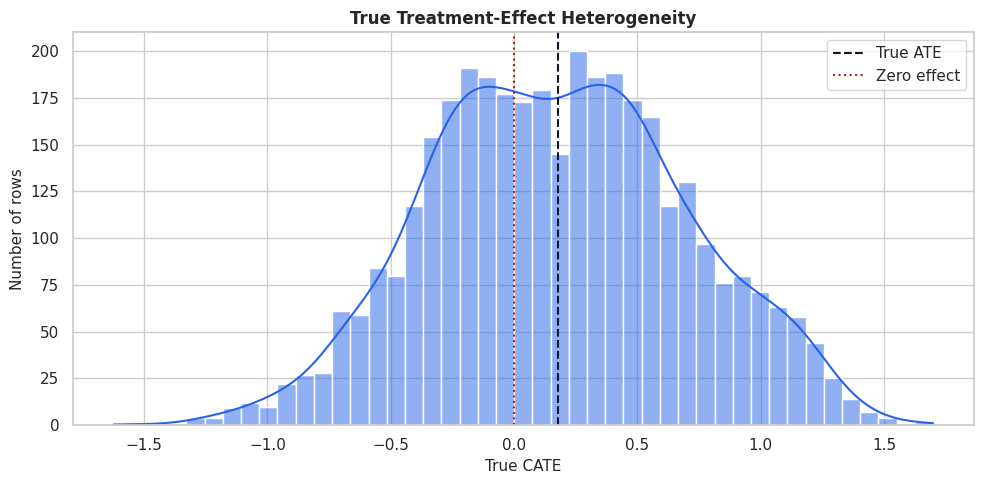

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(causal_df["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(causal_df["true_cate"].mean(), color="#111827", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(0, color="#b91c1c", linestyle=":", linewidth=1.5, label="Zero effect")
ax.set_title("True Treatment-Effect Heterogeneity")
ax.set_xlabel("True CATE")
ax.set_ylabel("Number of rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution has both low-benefit and high-benefit regions. A point-estimate-only policy will tend to focus on the right tail, while an uncertainty-aware policy will ask whether that right tail is estimated precisely enough to trust.

## Naive Treated-Control Difference

Before using EconML, we compute the raw treated-control difference. This is not a causal estimate because treatment assignment is confounded. The point is to show why uncertainty around a naive contrast is not enough: a precise biased estimate can still be wrong.

In [7]:
raw_group_summary = (
    causal_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        outcome_mean=("outcome", "mean"),
        outcome_std=("outcome", "std"),
        true_cate_mean=("true_cate", "mean"),
        true_propensity_mean=("true_propensity", "mean"),
        support_risk_rate=("support_risk", "mean"),
    )
    .reset_index()
)

raw_difference = raw_group_summary.loc[raw_group_summary["treatment"] == 1, "outcome_mean"].iloc[0] - raw_group_summary.loc[raw_group_summary["treatment"] == 0, "outcome_mean"].iloc[0]
raw_difference_vs_truth = pd.DataFrame(
    {
        "quantity": ["raw_treated_minus_control", "true_ate", "raw_minus_true_ate"],
        "value": [raw_difference, causal_df["true_cate"].mean(), raw_difference - causal_df["true_cate"].mean()],
    }
)

raw_group_summary.to_csv(TABLE_DIR / "09_raw_group_summary.csv", index=False)
raw_difference_vs_truth.to_csv(TABLE_DIR / "09_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_vs_truth)

,treatment,rows,outcome_mean,outcome_std,true_cate_mean,true_propensity_mean,support_risk_rate
0,0,1905,1.143319,1.136881,0.067792,0.400417,0.197900
1,1,1695,2.088069,1.482935,0.307007,0.556426,0.328024


,quantity,value
0,raw_treated_minus_control,0.944750
1,true_ate,0.180423
2,raw_minus_true_ate,0.764328


The treated group differs from the control group before we adjust for covariates. This means the raw difference mixes treatment effect, selection bias, and baseline outcome differences. EconML's uncertainty intervals will be more useful only after we address this confounding structure.

## Covariate Balance

This cell computes standardized mean differences between treated and control groups. A standardized mean difference larger than about `0.10` is a practical warning sign that treatment and control groups differ on that feature.

In [8]:
feature_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "account_tenure",
    "region_risk",
    "seasonality_index",
    "device_stability",
    "high_need_segment",
    "support_risk",
]

balance_rows = []
for feature in feature_cols:
    treated_values = causal_df.loc[causal_df["treatment"] == 1, feature]
    control_values = causal_df.loc[causal_df["treatment"] == 0, feature]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    smd = (treated_values.mean() - control_values.mean()) / pooled_sd
    balance_rows.append(
        {
            "feature": feature,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_mean_difference": smd,
            "absolute_smd": abs(smd),
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("absolute_smd", ascending=False)
balance_table.to_csv(TABLE_DIR / "09_covariate_balance.csv", index=False)
display(balance_table)

,feature,treated_mean,control_mean,standardized_mean_difference,absolute_smd
0,baseline_need,0.283993,-0.225164,0.515540,0.515540
9,high_need_segment,0.398230,0.213123,0.410047,0.410047
10,support_risk,0.328024,0.197900,0.298770,0.298770
1,prior_engagement,0.164212,-0.123947,0.286903,0.286903
2,friction_score,-0.149335,0.129537,-0.278945,0.278945
3,content_affinity,0.115722,-0.096766,0.212210,0.212210
7,seasonality_index,0.115685,-0.079604,0.197588,0.197588
4,price_sensitivity,0.404911,0.434985,-0.148647,0.148647
6,region_risk,0.242478,0.299738,-0.129041,0.129041
5,account_tenure,53.521709,54.869750,-0.043527,0.043527


Several covariates are imbalanced, especially features that also affect the outcome or the true CATE. This reinforces why causal modeling has to adjust for observed confounding before we attach meaning to interval estimates.

## Balance Plot

The table above is useful, but a plot makes the severity and direction of imbalance easier to scan. This plot is also a good report artifact because it explains why naive comparisons are not credible.

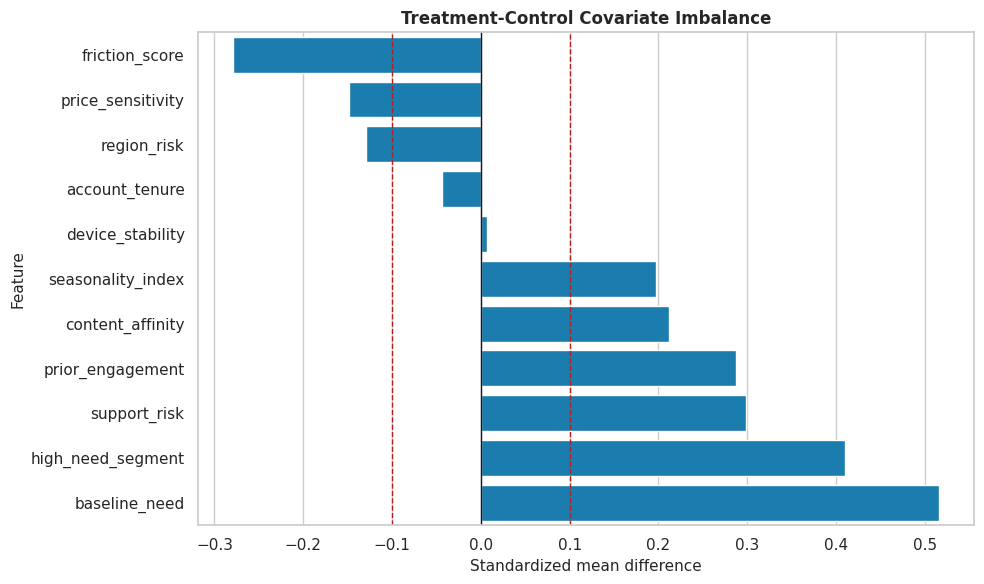

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_balance = balance_table.sort_values("standardized_mean_difference")
sns.barplot(data=plot_balance, x="standardized_mean_difference", y="feature", color="#0284c7", ax=ax)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#b91c1c", linestyle="--", linewidth=1)
ax.axvline(-0.10, color="#b91c1c", linestyle="--", linewidth=1)
ax.set_title("Treatment-Control Covariate Imbalance")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()

The dashed lines mark a common practical threshold for imbalance. The visible imbalance means our uncertainty discussion should focus on adjusted estimators rather than raw group differences.

## Propensity Overlap

Confidence intervals become less trustworthy when treated and control rows do not overlap well. Here we use the known synthetic propensity to show the assignment support before fitting any estimated model.

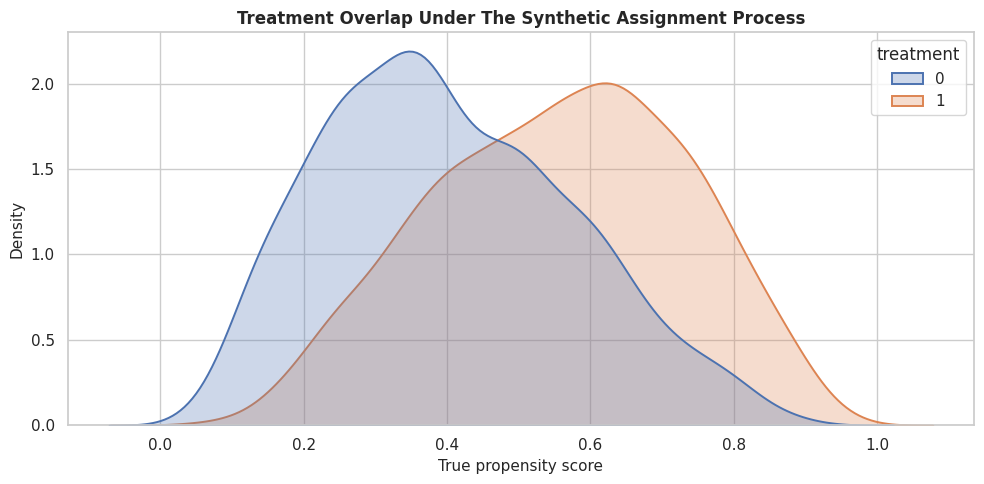

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=causal_df,
    x="true_propensity",
    hue="treatment",
    common_norm=False,
    fill=True,
    alpha=0.28,
    linewidth=1.4,
    ax=ax,
)
ax.set_title("Treatment Overlap Under The Synthetic Assignment Process")
ax.set_xlabel("True propensity score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

The two distributions overlap, but they are not identical. The upper and lower propensity regions will tend to have wider CATE intervals because the estimator has fewer comparable treated-control contrasts there.

## Train-Test Split

We split the data before fitting models so that CATE recovery, interval width, and policy diagnostics are evaluated on held-out rows. This mirrors a practical workflow where we train a model, then examine how its estimates behave on data not used for fitting.

In [11]:
train_df, test_df = train_test_split(
    causal_df,
    test_size=0.35,
    random_state=202609,
    stratify=causal_df[["treatment", "support_risk"]],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "treatment_rate": [train_df["treatment"].mean(), test_df["treatment"].mean()],
        "support_risk_rate": [train_df["support_risk"].mean(), test_df["support_risk"].mean()],
        "true_ate": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
        "outcome_mean": [train_df["outcome"].mean(), test_df["outcome"].mean()],
    }
)

split_summary.to_csv(TABLE_DIR / "09_train_test_split_summary.csv", index=False)
display(split_summary)

,split,rows,treatment_rate,support_risk_rate,true_ate,outcome_mean
0,train,2340,0.470940,0.259402,0.173662,1.574406
1,test,1260,0.470635,0.258730,0.192978,1.613643


The train and test splits have similar treatment and support-risk rates. That matters because large split differences would make later model diagnostics harder to interpret.

## Model Matrices

EconML separates the treatment, outcome, and covariates. In this tutorial all observed pre-treatment covariates are used as effect modifiers `X`. We keep the setup simple so the uncertainty behavior is the main focus.

In [12]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df["outcome"].to_numpy()
y_test = test_df["outcome"].to_numpy()
t_train = train_df["treatment"].to_numpy()
t_test = test_df["treatment"].to_numpy()
true_tau_train = train_df["true_cate"].to_numpy()
true_tau_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    {
        "object": ["X_train", "X_test", "y_train", "t_train"],
        "shape_or_length": [X_train.shape, X_test.shape, len(y_train), len(t_train)],
        "description": [
            "Observed pre-treatment covariates used for heterogeneity.",
            "Held-out covariates used for evaluation and policy diagnostics.",
            "Observed training outcomes.",
            "Observed training treatment indicators.",
        ],
    }
)

matrix_summary.to_csv(TABLE_DIR / "09_model_matrix_summary.csv", index=False)
display(matrix_summary)

,object,shape_or_length,description
0,X_train,"(2340, 11)",Observed pre-treatment covariates used for het...
1,X_test,"(1260, 11)",Held-out covariates used for evaluation and po...
2,y_train,2340,Observed training outcomes.
3,t_train,2340,Observed training treatment indicators.


The matrices are now in the structure that EconML expects. The same `feature_cols` list will be reused in the estimators and later diagnostic tables so the analysis stays consistent.

## Nuisance Diagnostics

DML estimators use nuisance models for the outcome and treatment assignment processes. If these models are weak, treatment-effect estimates and intervals can degrade. This cell trains simple diagnostic nuisance models on the training split and evaluates them on the test split.

In [13]:
propensity_diagnostic = RandomForestClassifier(
    n_estimators=220,
    min_samples_leaf=25,
    random_state=202609,
    n_jobs=-1,
)
propensity_diagnostic.fit(X_train, t_train)
propensity_pred = np.clip(propensity_diagnostic.predict_proba(X_test)[:, 1], 1e-4, 1 - 1e-4)

outcome_features_train = X_train.assign(treatment=t_train)
outcome_features_test = X_test.assign(treatment=t_test)
outcome_diagnostic = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=20,
    random_state=202610,
    n_jobs=-1,
)
outcome_diagnostic.fit(outcome_features_train, y_train)
outcome_pred = outcome_diagnostic.predict(outcome_features_test)

nuisance_diagnostics = pd.DataFrame(
    [
        {
            "model": "propensity_model",
            "metric_1": "roc_auc",
            "value_1": roc_auc_score(t_test, propensity_pred),
            "metric_2": "log_loss",
            "value_2": log_loss(t_test, propensity_pred),
        },
        {
            "model": "outcome_model",
            "metric_1": "rmse",
            "value_1": np.sqrt(mean_squared_error(y_test, outcome_pred)),
            "metric_2": "mae",
            "value_2": mean_absolute_error(y_test, outcome_pred),
        },
    ]
)

nuisance_diagnostics.to_csv(TABLE_DIR / "09_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)

,model,metric_1,value_1,metric_2,value_2
0,propensity_model,roc_auc,0.711525,log_loss,0.623116
1,outcome_model,rmse,0.921185,mae,0.724830


The propensity model has predictive power, which is expected in an observational setup. That reminds us treatment is not random, and it also helps explain why interval width will vary across the covariate space.

## Estimated Propensity Buckets

This cell bins held-out rows by estimated propensity. The purpose is to create a support diagnostic we can join to CATE intervals later. Rows near 0 or 1 usually have less counterfactual support than rows near 0.5.

In [14]:
eval_df = test_df[feature_cols + ["treatment", "outcome", "true_cate", "true_propensity"]].copy()
eval_df["estimated_propensity"] = propensity_pred
eval_df["overlap_score"] = np.minimum(eval_df["estimated_propensity"], 1 - eval_df["estimated_propensity"])
eval_df["propensity_bucket"] = pd.cut(
    eval_df["estimated_propensity"],
    bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    include_lowest=True,
)

propensity_bucket_summary = (
    eval_df.groupby("propensity_bucket", observed=True)
    .agg(
        rows=("outcome", "size"),
        treatment_rate=("treatment", "mean"),
        support_risk_rate=("support_risk", "mean"),
        mean_overlap_score=("overlap_score", "mean"),
        true_cate_mean=("true_cate", "mean"),
    )
    .reset_index()
)

propensity_bucket_summary.to_csv(TABLE_DIR / "09_propensity_bucket_summary.csv", index=False)
display(propensity_bucket_summary)

,propensity_bucket,rows,treatment_rate,support_risk_rate,mean_overlap_score,true_cate_mean
0,"(-0.001, 0.2]",25,0.160000,0.000000,0.163054,-0.458251
1,"(0.2, 0.4]",413,0.278450,0.162228,0.316678,-0.145648
2,"(0.4, 0.6]",530,0.490566,0.283019,0.448125,0.239583
3,"(0.6, 0.8]",291,0.731959,0.371134,0.327466,0.642599
4,"(0.8, 1.0]",1,1.000000,1.000000,0.161373,0.785962


The bucket table turns abstract overlap into something visible. Later, if interval widths are largest in the edge buckets, we will have a concrete explanation: those rows have less balanced treated-control support.

## Fit A Causal Forest With Intervals

`CausalForestDML` is a natural estimator for this notebook because it can estimate nonlinear CATEs and return uncertainty intervals. The forest uses machine-learning nuisance models and honest splitting internally, then estimates heterogeneous effects from the residualized treatment and outcome signal.

In [15]:
forest = CausalForestDML(
    model_y=RandomForestRegressor(
        n_estimators=220,
        min_samples_leaf=20,
        random_state=202611,
        n_jobs=-1,
    ),
    model_t=RandomForestClassifier(
        n_estimators=220,
        min_samples_leaf=25,
        random_state=202612,
        n_jobs=-1,
    ),
    n_estimators=240,
    min_samples_leaf=20,
    max_samples=0.45,
    discrete_treatment=True,
    cv=3,
    random_state=202613,
    inference=True,
)

forest.fit(y_train, t_train, X=X_train)
forest_tau_train = forest.effect(X_train)
forest_tau_test = forest.effect(X_test)
forest_lower_test, forest_upper_test = forest.effect_interval(X_test, alpha=0.05)
forest_ate = forest.ate(X_test)
forest_ate_lower, forest_ate_upper = forest.ate_interval(X_test, alpha=0.05)

print(f"Causal forest held-out ATE estimate: {forest_ate:.4f}")
print(f"95% ATE interval: [{forest_ate_lower:.4f}, {forest_ate_upper:.4f}]")

Causal forest held-out ATE estimate: 0.3048
95% ATE interval: [0.0691, 0.5406]


The forest now gives us both point estimates and intervals. The ATE interval summarizes uncertainty for the average held-out effect, while the row-level interval arrays will let us inspect uncertainty across the covariate space.

## Fit An Interpretable Linear DML Baseline

A causal forest is flexible, but it is useful to compare it with a simpler model. `LinearDML` estimates a linear CATE function and can return statsmodels-style inference intervals. If the linear model performs much worse on a nonlinear data-generating process, that helps explain why model choice affects both point estimates and uncertainty.

In [16]:
linear_dml = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=180,
        min_samples_leaf=25,
        random_state=202614,
        n_jobs=-1,
    ),
    model_t=RandomForestClassifier(
        n_estimators=180,
        min_samples_leaf=25,
        random_state=202615,
        n_jobs=-1,
    ),
    discrete_treatment=True,
    cv=3,
    random_state=202616,
)

linear_dml.fit(y_train, t_train, X=X_train, inference="statsmodels")
linear_tau_test = linear_dml.effect(X_test)
linear_lower_test, linear_upper_test = linear_dml.effect_interval(X_test, alpha=0.05)
linear_ate = linear_dml.ate(X_test)
linear_ate_lower, linear_ate_upper = linear_dml.ate_interval(X_test, alpha=0.05)

print(f"LinearDML held-out ATE estimate: {linear_ate:.4f}")
print(f"95% ATE interval: [{linear_ate_lower:.4f}, {linear_ate_upper:.4f}]")

LinearDML held-out ATE estimate: 0.2931
95% ATE interval: [0.2160, 0.3703]


The linear baseline gives a second view of uncertainty. It is more restrictive than the forest, so we should not expect it to recover all nonlinear heterogeneity, but it is valuable as a transparent comparison point.

## Compare Model Recovery And Interval Coverage

Because we know the true CATE, we can compute teaching diagnostics that would not be available in production: CATE RMSE, correlation with truth, and empirical interval coverage. These checks help students understand what the intervals are doing.

In [17]:
def summarize_cate_model(name, estimate, lower, upper, ate, ate_lower, ate_upper):
    """Create one comparable row of CATE and interval diagnostics."""
    width = upper - lower
    return {
        "estimator": name,
        "true_test_ate": true_tau_test.mean(),
        "estimated_test_ate": ate,
        "ate_ci_lower": ate_lower,
        "ate_ci_upper": ate_upper,
        "ate_interval_covers_truth": ate_lower <= true_tau_test.mean() <= ate_upper,
        "cate_rmse": np.sqrt(mean_squared_error(true_tau_test, estimate)),
        "cate_mae": mean_absolute_error(true_tau_test, estimate),
        "cate_correlation": np.corrcoef(true_tau_test, estimate)[0, 1],
        "median_interval_width": np.median(width),
        "mean_interval_width": np.mean(width),
        "row_level_coverage": np.mean((true_tau_test >= lower) & (true_tau_test <= upper)),
        "share_intervals_above_zero": np.mean(lower > 0),
        "share_point_estimates_above_zero": np.mean(estimate > 0),
    }


model_summary = pd.DataFrame(
    [
        summarize_cate_model("CausalForestDML", forest_tau_test, forest_lower_test, forest_upper_test, forest_ate, forest_ate_lower, forest_ate_upper),
        summarize_cate_model("LinearDML", linear_tau_test, linear_lower_test, linear_upper_test, linear_ate, linear_ate_lower, linear_ate_upper),
    ]
)

model_summary.to_csv(TABLE_DIR / "09_cate_interval_model_summary.csv", index=False)
display(model_summary)

,estimator,true_test_ate,estimated_test_ate,ate_ci_lower,ate_ci_upper,ate_interval_covers_truth,cate_rmse,cate_mae,cate_correlation,median_interval_width,mean_interval_width,row_level_coverage,share_intervals_above_zero,share_point_estimates_above_zero
0,CausalForestDML,0.192978,0.304832,0.069091,0.540573,True,0.342216,0.270682,0.912588,0.420248,0.445072,0.476190,0.628571,0.896032
1,LinearDML,0.192978,0.293120,0.215987,0.370252,False,0.206662,0.169935,0.940356,0.546364,0.551858,0.788889,0.547619,0.715873


The summary separates three ideas: whether the average-effect interval covers the true ATE, how well the model recovers row-level heterogeneity, and how wide the row-level intervals are. Strong average inference does not automatically mean every individual CATE is precise.

## CATE Recovery Scatter With Interval Width

This plot compares estimated and true CATE for the causal forest. The color represents interval width, so we can see whether the largest errors tend to occur in regions where the model is less certain.

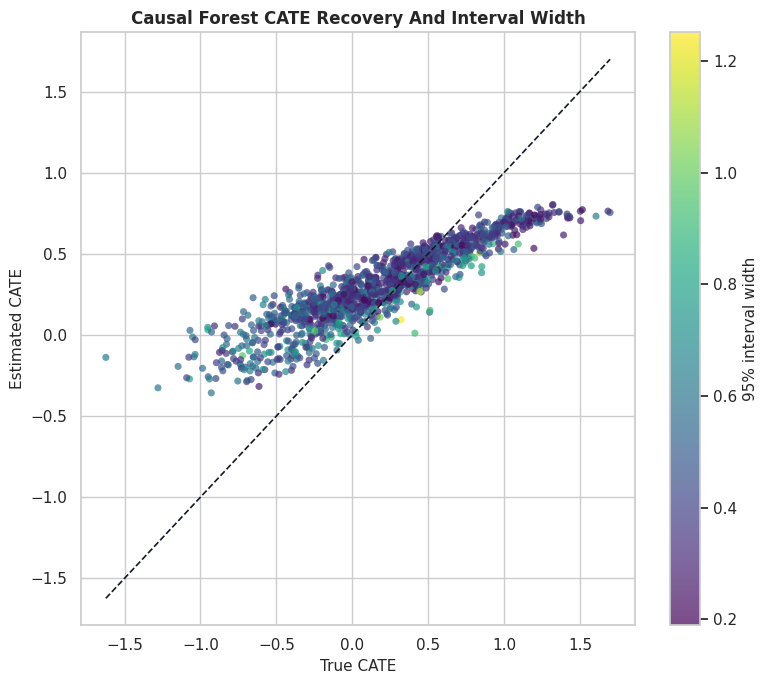

In [18]:
eval_df["forest_cate"] = forest_tau_test
eval_df["forest_lower_95"] = forest_lower_test
eval_df["forest_upper_95"] = forest_upper_test
eval_df["forest_interval_width"] = forest_upper_test - forest_lower_test
eval_df["linear_cate"] = linear_tau_test
eval_df["linear_lower_95"] = linear_lower_test
eval_df["linear_upper_95"] = linear_upper_test
eval_df["linear_interval_width"] = linear_upper_test - linear_lower_test

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    eval_df["true_cate"],
    eval_df["forest_cate"],
    c=eval_df["forest_interval_width"],
    cmap="viridis",
    alpha=0.70,
    s=26,
    linewidth=0,
)
lims = [min(eval_df["true_cate"].min(), eval_df["forest_cate"].min()), max(eval_df["true_cate"].max(), eval_df["forest_cate"].max())]
ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Causal Forest CATE Recovery And Interval Width")
ax.set_xlabel("True CATE")
ax.set_ylabel("Estimated CATE")
cb = fig.colorbar(scatter, ax=ax)
cb.set_label("95% interval width")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_cate_recovery_with_interval_width.png", dpi=160, bbox_inches="tight")
plt.show()

The diagonal line marks perfect recovery. Points far from the diagonal are estimation errors; the color scale helps us see whether those errors are concentrated in high-uncertainty regions.

## Interval Calibration By Estimated CATE Decile

A useful diagnostic is to group rows by estimated CATE and compare the average estimate, average true CATE, and average interval. In real data, we would not have the true CATE column, but this teaching view makes the logic of calibration easier to see.

In [19]:
eval_df["forest_cate_decile"] = pd.qcut(eval_df["forest_cate"], q=10, labels=False, duplicates="drop") + 1

interval_calibration = (
    eval_df.groupby("forest_cate_decile", observed=True)
    .agg(
        rows=("forest_cate", "size"),
        mean_estimated_cate=("forest_cate", "mean"),
        mean_true_cate=("true_cate", "mean"),
        mean_lower_95=("forest_lower_95", "mean"),
        mean_upper_95=("forest_upper_95", "mean"),
        median_interval_width=("forest_interval_width", "median"),
        row_level_coverage=("true_cate", lambda s: np.mean((s >= eval_df.loc[s.index, "forest_lower_95"]) & (s <= eval_df.loc[s.index, "forest_upper_95"]))),
        support_risk_rate=("support_risk", "mean"),
    )
    .reset_index()
)

interval_calibration.to_csv(TABLE_DIR / "09_interval_calibration_by_decile.csv", index=False)
display(interval_calibration)

,forest_cate_decile,rows,mean_estimated_cate,mean_true_cate,mean_lower_95,mean_upper_95,median_interval_width,row_level_coverage,support_risk_rate
0,1,126,-0.133045,-0.580576,-0.400463,0.134373,0.525297,0.246032,0.984127
1,2,126,0.058667,-0.300900,-0.199407,0.316742,0.493275,0.373016,0.571429
2,3,126,0.144314,-0.155224,-0.088001,0.376630,0.459862,0.341270,0.285714
3,4,126,0.202023,-0.077513,-0.011124,0.415170,0.412260,0.341270,0.142857
4,5,126,0.267299,0.069836,0.060049,0.474548,0.379949,0.492063,0.158730
5,6,126,0.332673,0.241113,0.124779,0.540567,0.395627,0.682540,0.111111
6,7,126,0.412295,0.383496,0.181514,0.643077,0.421070,0.777778,0.206349
7,8,126,0.489829,0.527150,0.267438,0.712220,0.415599,0.785714,0.111111
8,9,126,0.574596,0.729585,0.383328,0.765864,0.361802,0.603175,0.015873
9,10,126,0.699671,1.092816,0.504849,0.894492,0.386640,0.119048,0.000000


The decile table shows whether higher estimated CATE groups also have higher true CATE on average. The interval columns make the ranking less brittle by showing how much uncertainty surrounds each group.

## Calibration Plot With Decile-Level Intervals

The table is precise, but the plot makes the ranking pattern clearer. Each dot is a decile of estimated forest CATE. The vertical bars are the average lower and upper interval bounds for that decile, not a new interval for the decile mean.

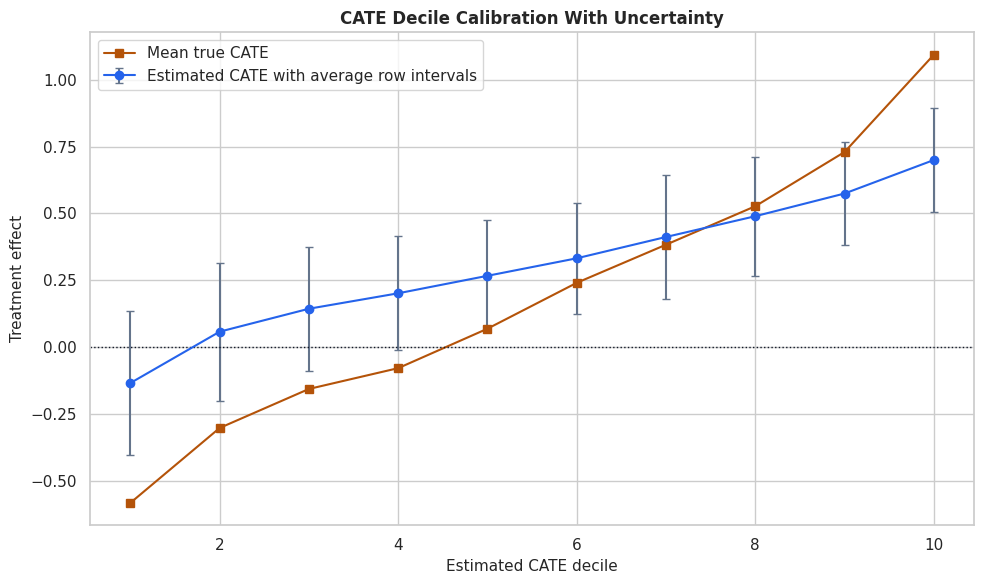

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    interval_calibration["forest_cate_decile"],
    interval_calibration["mean_estimated_cate"],
    yerr=[
        interval_calibration["mean_estimated_cate"] - interval_calibration["mean_lower_95"],
        interval_calibration["mean_upper_95"] - interval_calibration["mean_estimated_cate"],
    ],
    fmt="o-",
    color="#2563eb",
    ecolor="#64748b",
    capsize=3,
    label="Estimated CATE with average row intervals",
)
ax.plot(interval_calibration["forest_cate_decile"], interval_calibration["mean_true_cate"], marker="s", color="#b45309", label="Mean true CATE")
ax.axhline(0, color="#111827", linewidth=1, linestyle=":")
ax.set_title("CATE Decile Calibration With Uncertainty")
ax.set_xlabel("Estimated CATE decile")
ax.set_ylabel("Treatment effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_interval_calibration_by_decile.png", dpi=160, bbox_inches="tight")
plt.show()

The upward pattern tells us the forest ranking contains useful signal. The error bars remind us that the distance between neighboring deciles may not be meaningful when intervals overlap heavily.

## Interval Width By Propensity Support

Now we connect uncertainty back to overlap. If the model has weaker counterfactual support in low-overlap rows, the interval width should generally be larger there.

In [21]:
width_by_propensity = (
    eval_df.groupby("propensity_bucket", observed=True)
    .agg(
        rows=("forest_cate", "size"),
        treatment_rate=("treatment", "mean"),
        mean_overlap_score=("overlap_score", "mean"),
        median_interval_width=("forest_interval_width", "median"),
        mean_interval_width=("forest_interval_width", "mean"),
        row_level_coverage=("true_cate", lambda s: np.mean((s >= eval_df.loc[s.index, "forest_lower_95"]) & (s <= eval_df.loc[s.index, "forest_upper_95"]))),
        support_risk_rate=("support_risk", "mean"),
    )
    .reset_index()
)

width_by_propensity.to_csv(TABLE_DIR / "09_interval_width_by_propensity.csv", index=False)
display(width_by_propensity)

,propensity_bucket,rows,treatment_rate,mean_overlap_score,median_interval_width,mean_interval_width,row_level_coverage,support_risk_rate
0,"(-0.001, 0.2]",25,0.160000,0.163054,0.558920,0.506457,0.040000,0.000000
1,"(0.2, 0.4]",413,0.278450,0.316678,0.405716,0.420924,0.307506,0.162228
2,"(0.4, 0.6]",530,0.490566,0.448125,0.414920,0.432456,0.562264,0.283019
3,"(0.6, 0.8]",291,0.731959,0.327466,0.452877,0.495306,0.594502,0.371134
4,"(0.8, 1.0]",1,1.000000,0.161373,0.951958,0.951958,1.000000,1.000000


This table translates overlap into interval behavior. Buckets with lower overlap scores or higher support-risk rates are the places where row-level CATE estimates should be treated with extra caution.

## Interval Width Scatter

This plot shows each held-out row as a point. The x-axis is estimated overlap support, and the y-axis is the forest interval width. A downward pattern means intervals get narrower as treated-control support improves.

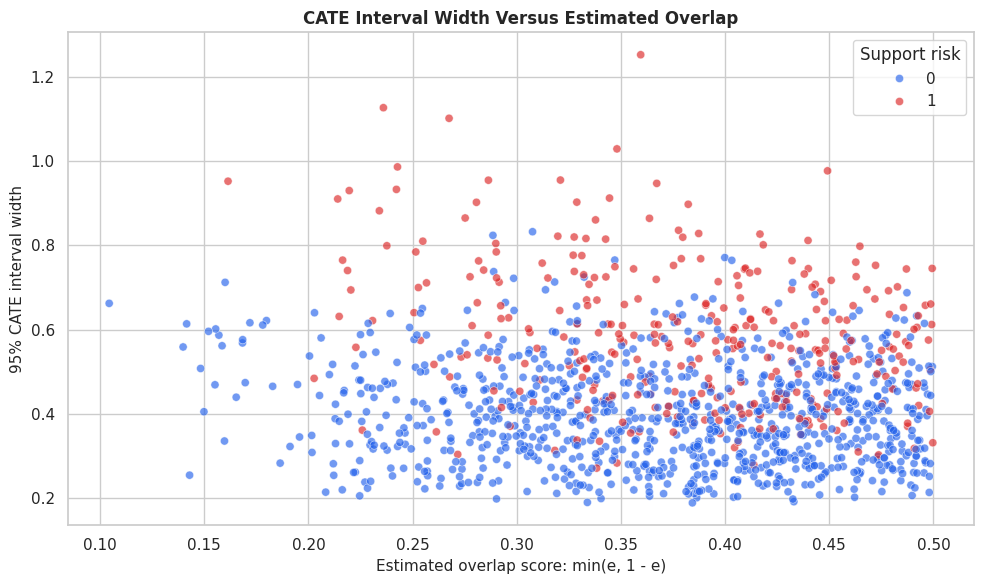

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=eval_df,
    x="overlap_score",
    y="forest_interval_width",
    hue="support_risk",
    palette={0: "#2563eb", 1: "#dc2626"},
    alpha=0.65,
    s=35,
    ax=ax,
)
ax.set_title("CATE Interval Width Versus Estimated Overlap")
ax.set_xlabel("Estimated overlap score: min(e, 1 - e)")
ax.set_ylabel("95% CATE interval width")
ax.legend(title="Support risk")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_interval_width_vs_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

The plot links a statistical object to a data-support explanation. Wide intervals are not random noise in the report; they often point to places where the data provide weaker counterfactual comparisons.

## Interval Width Drivers

A quick way to explain interval width is to model it as a function of the observed covariates. This is not a causal model; it is a diagnostic model that asks which features are associated with more uncertain treatment-effect estimates.

In [23]:
width_model = RandomForestRegressor(
    n_estimators=260,
    min_samples_leaf=18,
    random_state=202617,
    n_jobs=-1,
)
width_model.fit(X_test, eval_df["forest_interval_width"])

width_driver_table = (
    pd.DataFrame({"feature": feature_cols, "importance": width_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

width_driver_table.to_csv(TABLE_DIR / "09_interval_width_driver_importance.csv", index=False)
display(width_driver_table)

,feature,importance
0,support_risk,0.461183
1,baseline_need,0.229668
2,price_sensitivity,0.084462
3,friction_score,0.067983
4,content_affinity,0.061727
5,prior_engagement,0.032431
6,device_stability,0.024123
7,seasonality_index,0.019806
8,account_tenure,0.015230
9,region_risk,0.002655


The driver table helps explain which features are associated with precision rather than effect size. If a feature drives interval width, that feature may deserve extra support checks before using CATE estimates for targeting.

## Plot Interval Width Drivers

The feature-importance table is useful for exact values, while a bar chart gives a faster read of the main uncertainty drivers.

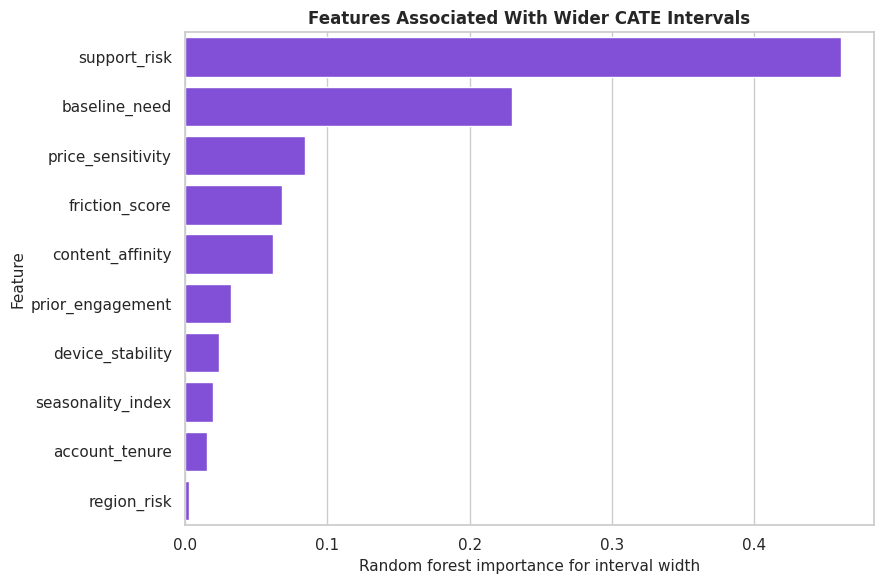

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=width_driver_table.head(10), x="importance", y="feature", color="#7c3aed", ax=ax)
ax.set_title("Features Associated With Wider CATE Intervals")
ax.set_xlabel("Random forest importance for interval width")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_interval_width_driver_importance.png", dpi=160, bbox_inches="tight")
plt.show()

The highest-ranked features tell us where uncertainty concentrates. In a real analysis, this would motivate targeted diagnostics, more data collection, or a more conservative policy in those segments.

## ATE Uncertainty Versus CATE Uncertainty

Average effects are often estimated more precisely than individual effects because averaging cancels some noise. This cell puts ATE intervals beside row-level CATE interval summaries so readers do not confuse the two.

In [25]:
ate_vs_cate_uncertainty = pd.DataFrame(
    [
        {
            "estimator": "CausalForestDML",
            "ate_estimate": forest_ate,
            "ate_ci_lower": forest_ate_lower,
            "ate_ci_upper": forest_ate_upper,
            "ate_interval_width": forest_ate_upper - forest_ate_lower,
            "median_row_cate_interval_width": np.median(eval_df["forest_interval_width"]),
            "mean_row_cate_interval_width": eval_df["forest_interval_width"].mean(),
        },
        {
            "estimator": "LinearDML",
            "ate_estimate": linear_ate,
            "ate_ci_lower": linear_ate_lower,
            "ate_ci_upper": linear_ate_upper,
            "ate_interval_width": linear_ate_upper - linear_ate_lower,
            "median_row_cate_interval_width": np.median(eval_df["linear_interval_width"]),
            "mean_row_cate_interval_width": eval_df["linear_interval_width"].mean(),
        },
    ]
)

ate_vs_cate_uncertainty.to_csv(TABLE_DIR / "09_ate_vs_cate_uncertainty.csv", index=False)
display(ate_vs_cate_uncertainty)

,estimator,ate_estimate,ate_ci_lower,ate_ci_upper,ate_interval_width,median_row_cate_interval_width,mean_row_cate_interval_width
0,CausalForestDML,0.304832,0.069091,0.540573,0.471482,0.420248,0.445072
1,LinearDML,0.293120,0.215987,0.370252,0.154265,0.546364,0.551858


The row-level intervals are much wider than the ATE interval. This is the normal tradeoff: personalization is more granular, so it usually carries more uncertainty than a single average-effect estimate.

## Alpha Levels And Interval Width

A 95% interval is not the only possible choice. Wider intervals correspond to higher confidence levels, and narrower intervals correspond to lower confidence levels. This cell computes interval width and teaching coverage for several alpha values.

In [26]:
alpha_rows = []
for alpha in [0.20, 0.10, 0.05, 0.01]:
    lower_alpha, upper_alpha = forest.effect_interval(X_test, alpha=alpha)
    alpha_rows.append(
        {
            "confidence_level": 1 - alpha,
            "alpha": alpha,
            "mean_interval_width": np.mean(upper_alpha - lower_alpha),
            "median_interval_width": np.median(upper_alpha - lower_alpha),
            "row_level_coverage": np.mean((true_tau_test >= lower_alpha) & (true_tau_test <= upper_alpha)),
            "share_lower_bound_above_zero": np.mean(lower_alpha > 0),
        }
    )

alpha_sensitivity = pd.DataFrame(alpha_rows)
alpha_sensitivity.to_csv(TABLE_DIR / "09_alpha_sensitivity.csv", index=False)
display(alpha_sensitivity)

,confidence_level,alpha,mean_interval_width,median_interval_width,row_level_coverage,share_lower_bound_above_zero
0,0.80,0.20,0.291017,0.274785,0.32619,0.731746
1,0.90,0.10,0.373516,0.352683,0.40873,0.681746
2,0.95,0.05,0.445072,0.420248,0.47619,0.628571
3,0.99,0.01,0.584924,0.552299,0.58254,0.534127


Higher confidence levels produce wider intervals and usually higher teaching coverage. The last column shows the decision cost of being more conservative: fewer rows have a lower bound above zero.

## Plot Alpha Sensitivity

This figure shows the interval-width tradeoff across confidence levels. It is a compact way to explain why a policy can become more or less conservative depending on the interval standard used.

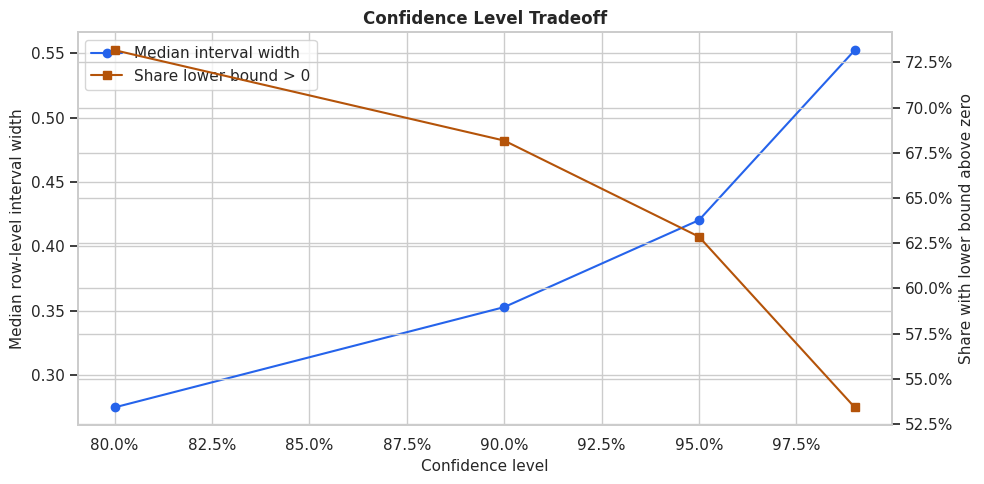

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(alpha_sensitivity["confidence_level"], alpha_sensitivity["median_interval_width"], marker="o", color="#2563eb", label="Median interval width")
ax2.plot(alpha_sensitivity["confidence_level"], alpha_sensitivity["share_lower_bound_above_zero"], marker="s", color="#b45309", label="Share lower bound > 0")

ax1.set_title("Confidence Level Tradeoff")
ax1.set_xlabel("Confidence level")
ax1.set_ylabel("Median row-level interval width")
ax2.set_ylabel("Share with lower bound above zero")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.xaxis.set_major_formatter(PercentFormatter(1.0))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_alpha_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The plot makes the decision tradeoff visible. If we demand very high confidence, the targetable group shrinks because the lower bound must clear a stricter uncertainty bar.

## Point-Estimate Targeting Versus Lower-Bound Targeting

Now we turn CATE estimates into policy rules. A point-estimate rule treats the highest estimated effects. A lower-bound rule treats rows whose conservative estimate is strongest. The comparison shows how uncertainty changes who gets selected.

In [28]:
top_share = 0.20
n_top = int(np.floor(top_share * len(eval_df)))

policy_df = eval_df.copy()
policy_df["point_rank_policy"] = 0
policy_df.loc[policy_df["forest_cate"].nlargest(n_top).index, "point_rank_policy"] = 1
policy_df["lower_bound_rank_policy"] = 0
policy_df.loc[policy_df["forest_lower_95"].nlargest(n_top).index, "lower_bound_rank_policy"] = 1
policy_df["positive_lower_bound_policy"] = (policy_df["forest_lower_95"] > 0).astype(int)

policy_summaries = []
for policy_col, label in [
    ("point_rank_policy", "Top 20% by point estimate"),
    ("lower_bound_rank_policy", "Top 20% by lower bound"),
    ("positive_lower_bound_policy", "All rows with lower bound > 0"),
]:
    selected = policy_df[policy_df[policy_col] == 1]
    policy_summaries.append(
        {
            "policy": label,
            "targeted_rows": len(selected),
            "target_rate": policy_df[policy_col].mean(),
            "mean_estimated_cate_targeted": selected["forest_cate"].mean(),
            "mean_lower_bound_targeted": selected["forest_lower_95"].mean(),
            "mean_true_cate_targeted": selected["true_cate"].mean(),
            "share_true_cate_negative": (selected["true_cate"] < 0).mean(),
            "median_interval_width": selected["forest_interval_width"].median(),
            "support_risk_rate": selected["support_risk"].mean(),
        }
    )

policy_comparison = pd.DataFrame(policy_summaries)
policy_comparison.to_csv(TABLE_DIR / "09_uncertainty_aware_policy_comparison.csv", index=False)
display(policy_comparison)

,policy,targeted_rows,target_rate,mean_estimated_cate_targeted,mean_lower_bound_targeted,mean_true_cate_targeted,share_true_cate_negative,median_interval_width,support_risk_rate
0,Top 20% by point estimate,252,0.200000,0.637133,0.444089,0.911201,0.000000,0.371197,0.007937
1,Top 20% by lower bound,252,0.200000,0.630662,0.451283,0.895040,0.000000,0.343445,0.000000
2,All rows with lower bound > 0,792,0.628571,0.444357,0.249531,0.467274,0.130051,0.370200,0.061869


The lower-bound policy may select a different group even when the treatment budget is the same. It favors rows with both high estimated benefit and enough precision to make the lower bound attractive.

## Plot Targeting Rules

This plot compares policy rules across three quantities: true targeted gain, conservative estimated gain, and support-risk share. The support-risk panel is especially useful because it shows whether a policy is leaning into less certain regions.

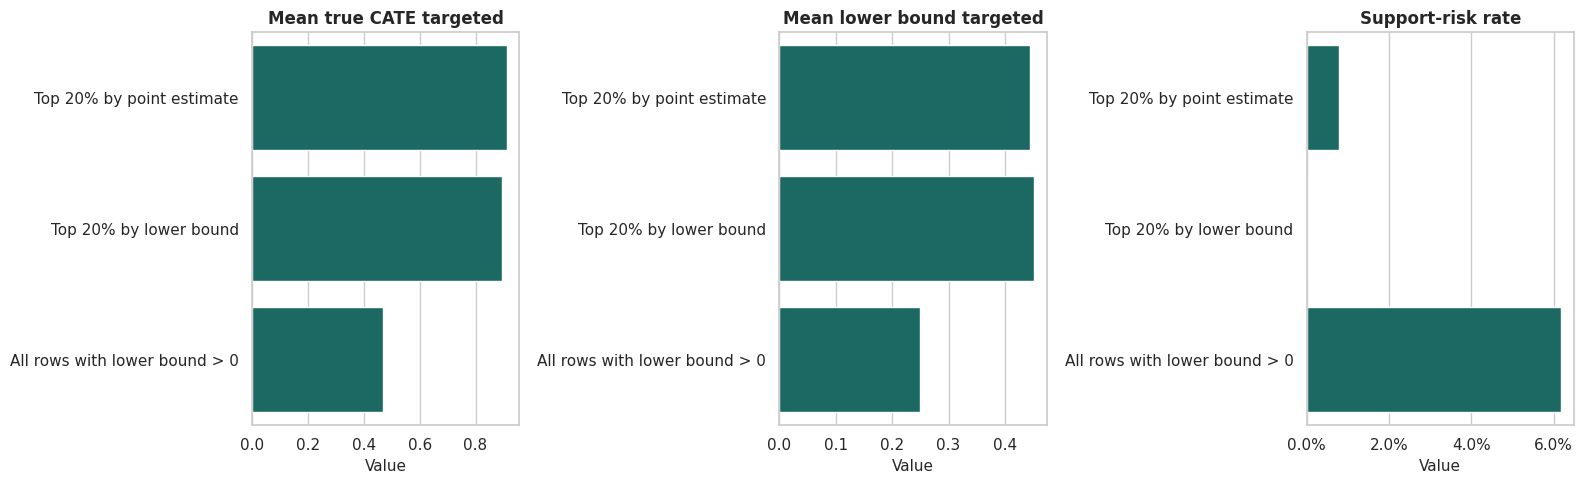

In [29]:
policy_plot_df = policy_comparison.melt(
    id_vars="policy",
    value_vars=["mean_true_cate_targeted", "mean_lower_bound_targeted", "support_risk_rate"],
    var_name="metric",
    value_name="value",
)
metric_labels = {
    "mean_true_cate_targeted": "Mean true CATE targeted",
    "mean_lower_bound_targeted": "Mean lower bound targeted",
    "support_risk_rate": "Support-risk rate",
}
policy_plot_df["metric"] = policy_plot_df["metric"].map(metric_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, policy_plot_df["metric"].unique()):
    subset = policy_plot_df[policy_plot_df["metric"] == metric]
    sns.barplot(data=subset, x="value", y="policy", color="#0f766e", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    if metric == "Support-risk rate":
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_uncertainty_aware_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The three-panel view shows the practical meaning of uncertainty-aware targeting. A rule can have slightly lower average point estimates but be more defensible if it avoids fragile high-uncertainty selections.

## Bootstrap Policy-Value Intervals

The CATE intervals describe row-level treatment-effect uncertainty. Policy stakeholders often also ask: how stable is the value of the selected policy group? This bootstrap resamples held-out rows and estimates the average predicted effect among selected rows. It is a lightweight policy-value uncertainty check, not a full model-refit bootstrap.

In [30]:
def bootstrap_policy_mean(frame, policy_col, value_col, n_bootstrap=1_000):
    """Bootstrap the mean predicted treatment effect among rows selected by a policy."""
    selected = frame.loc[frame[policy_col] == 1, value_col].to_numpy()
    if len(selected) == 0:
        return {"mean": np.nan, "ci_lower": np.nan, "ci_upper": np.nan, "selected_rows": 0}
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(selected, size=len(selected), replace=True)
        bootstrap_means.append(sample.mean())
    return {
        "mean": selected.mean(),
        "ci_lower": np.quantile(bootstrap_means, 0.025),
        "ci_upper": np.quantile(bootstrap_means, 0.975),
        "selected_rows": len(selected),
    }


bootstrap_rows = []
for policy_col, label in [
    ("point_rank_policy", "Top 20% by point estimate"),
    ("lower_bound_rank_policy", "Top 20% by lower bound"),
    ("positive_lower_bound_policy", "All rows with lower bound > 0"),
]:
    result = bootstrap_policy_mean(policy_df, policy_col, "forest_cate")
    result["policy"] = label
    bootstrap_rows.append(result)

bootstrap_policy_intervals = pd.DataFrame(bootstrap_rows)[["policy", "selected_rows", "mean", "ci_lower", "ci_upper"]]
bootstrap_policy_intervals.to_csv(TABLE_DIR / "09_bootstrap_policy_intervals.csv", index=False)
display(bootstrap_policy_intervals)

,policy,selected_rows,mean,ci_lower,ci_upper
0,Top 20% by point estimate,252,0.637133,0.627802,0.646134
1,Top 20% by lower bound,252,0.630662,0.620399,0.640281
2,All rows with lower bound > 0,792,0.444357,0.433538,0.457274


The bootstrap intervals summarize how stable the estimated policy value is over the held-out population. These intervals are usually narrower than individual CATE intervals because they average over selected rows.

## Plot Bootstrap Policy Intervals

The table gives exact values; the plot makes policy comparison easier. Each point is the average estimated CATE among selected rows, and the horizontal bar is the bootstrap interval.

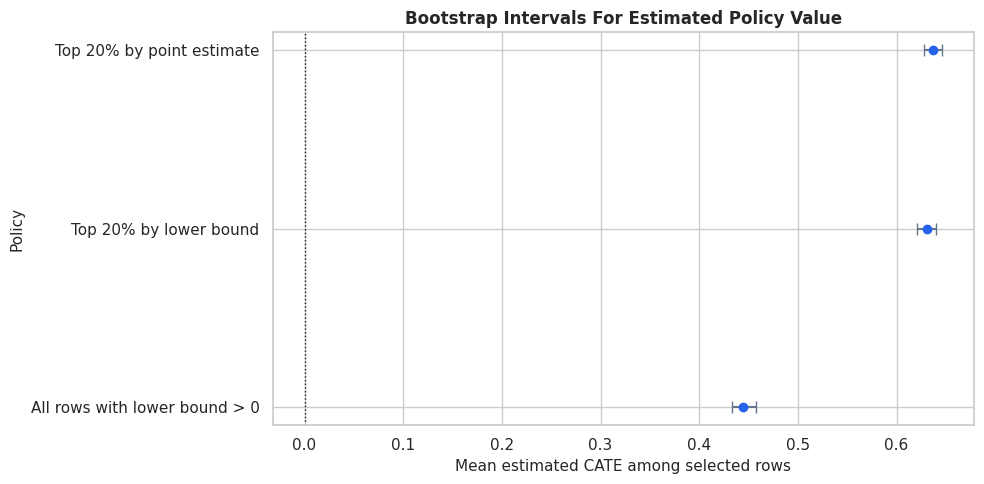

In [31]:
plot_boot = bootstrap_policy_intervals.sort_values("mean")
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=plot_boot["mean"],
    y=plot_boot["policy"],
    xerr=[plot_boot["mean"] - plot_boot["ci_lower"], plot_boot["ci_upper"] - plot_boot["mean"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.axvline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Bootstrap Intervals For Estimated Policy Value")
ax.set_xlabel("Mean estimated CATE among selected rows")
ax.set_ylabel("Policy")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_bootstrap_policy_intervals.png", dpi=160, bbox_inches="tight")
plt.show()

The policy-value intervals are a practical communication tool. They keep the report from implying false precision about a targeting rule's average benefit.

## Treatment Cost And Conservative Decisions

Many interventions have a cost: operational cost, user-experience cost, fairness cost, or opportunity cost. A treatment should clear that cost, not just be positive. This cell compares point-estimate and lower-bound rules under a simple cost threshold.

In [32]:
treatment_cost = 0.10
policy_df["point_above_cost_policy"] = (policy_df["forest_cate"] > treatment_cost).astype(int)
policy_df["lower_above_cost_policy"] = (policy_df["forest_lower_95"] > treatment_cost).astype(int)
policy_df["oracle_above_cost_policy"] = (policy_df["true_cate"] > treatment_cost).astype(int)

cost_policy_rows = []
for policy_col, label in [
    ("point_above_cost_policy", "Point estimate > cost"),
    ("lower_above_cost_policy", "Lower 95% bound > cost"),
    ("oracle_above_cost_policy", "Oracle true CATE > cost"),
]:
    selected = policy_df[policy_df[policy_col] == 1]
    cost_policy_rows.append(
        {
            "policy": label,
            "target_rate": policy_df[policy_col].mean(),
            "selected_rows": len(selected),
            "mean_true_net_gain_selected": (selected["true_cate"] - treatment_cost).mean() if len(selected) else np.nan,
            "population_true_net_gain": ((policy_df["true_cate"] - treatment_cost) * policy_df[policy_col]).mean(),
            "share_selected_with_negative_net_truth": ((selected["true_cate"] - treatment_cost) < 0).mean() if len(selected) else np.nan,
            "support_risk_rate": selected["support_risk"].mean() if len(selected) else np.nan,
        }
    )

cost_policy_comparison = pd.DataFrame(cost_policy_rows)
cost_policy_comparison.to_csv(TABLE_DIR / "09_cost_threshold_policy_comparison.csv", index=False)
display(cost_policy_comparison)

,policy,target_rate,selected_rows,mean_true_net_gain_selected,population_true_net_gain,share_selected_with_negative_net_truth,support_risk_rate
0,Point estimate > cost,0.808730,1019,0.245656,0.198669,0.313052,0.133464
1,Lower 95% bound > cost,0.488889,616,0.477371,0.233381,0.073052,0.032468
2,Oracle true CATE > cost,0.561111,707,0.469154,0.263247,0.000000,0.158416


The lower-bound rule is stricter because it requires the conservative estimate to exceed cost. This often reduces treatment volume, but it can also reduce the share of selected rows whose true net effect is negative in the teaching data.

## Lower-Bound Threshold Curve

A single threshold can feel arbitrary. This cell evaluates a range of lower-bound thresholds so we can see the tradeoff between treating more rows and demanding stronger conservative evidence.

In [33]:
threshold_rows = []
for threshold in np.linspace(-0.20, 0.70, 19):
    selected_mask = policy_df["forest_lower_95"] > threshold
    selected = policy_df[selected_mask]
    threshold_rows.append(
        {
            "lower_bound_threshold": threshold,
            "target_rate": selected_mask.mean(),
            "selected_rows": int(selected_mask.sum()),
            "population_true_gain": (policy_df["true_cate"] * selected_mask).mean(),
            "mean_true_cate_selected": selected["true_cate"].mean() if len(selected) else np.nan,
            "support_risk_rate": selected["support_risk"].mean() if len(selected) else np.nan,
            "median_interval_width": selected["forest_interval_width"].median() if len(selected) else np.nan,
        }
    )

threshold_curve = pd.DataFrame(threshold_rows)
threshold_curve.to_csv(TABLE_DIR / "09_lower_bound_threshold_curve.csv", index=False)
display(threshold_curve)

,lower_bound_threshold,target_rate,selected_rows,population_true_gain,mean_true_cate_selected,support_risk_rate,median_interval_width
0,-2.000000e-01,0.840476,1059,0.265379,0.315749,0.139754,0.401160
1,-1.500000e-01,0.813492,1025,0.272926,0.335499,0.122927,0.398025
2,-1.000000e-01,0.752381,948,0.282729,0.375779,0.098101,0.388864
3,-5.000000e-02,0.694444,875,0.291234,0.419376,0.081143,0.382451
4,-2.775558e-17,0.628571,792,0.293715,0.467274,0.061869,0.370200
5,5.000000e-02,0.556349,701,0.290454,0.522072,0.045649,0.364491
6,1.000000e-01,0.488889,616,0.282270,0.577371,0.032468,0.361591
7,1.500000e-01,0.411905,519,0.265066,0.643513,0.021195,0.360002
8,2.000000e-01,0.348413,439,0.247167,0.709409,0.013667,0.360887
9,2.500000e-01,0.288889,364,0.222570,0.770434,0.010989,0.356356


The threshold curve is a decision table. It shows how the treated population shrinks as the lower-bound standard rises, and how that affects expected gain and selected-segment composition.

## Plot Threshold Tradeoffs

This figure places the main threshold tradeoffs in one view. The ideal threshold depends on the intervention's cost, capacity, and tolerance for uncertain selections.

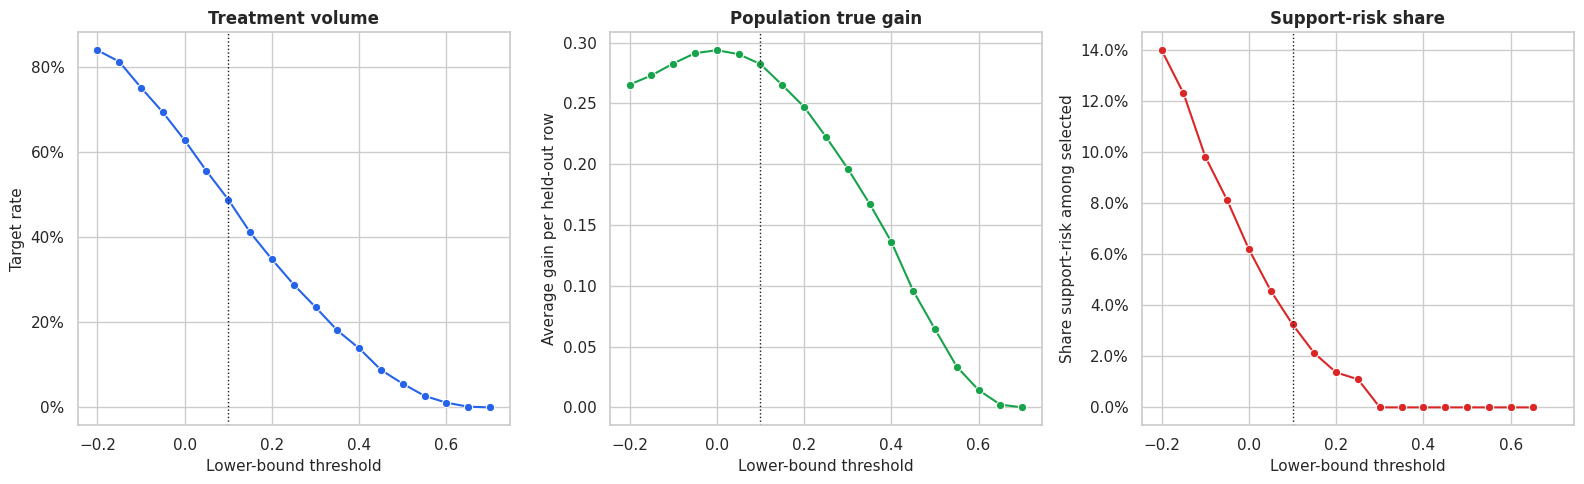

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

sns.lineplot(data=threshold_curve, x="lower_bound_threshold", y="target_rate", marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("Treatment volume")
axes[0].set_ylabel("Target rate")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

sns.lineplot(data=threshold_curve, x="lower_bound_threshold", y="population_true_gain", marker="o", ax=axes[1], color="#16a34a")
axes[1].set_title("Population true gain")
axes[1].set_ylabel("Average gain per held-out row")

sns.lineplot(data=threshold_curve, x="lower_bound_threshold", y="support_risk_rate", marker="o", ax=axes[2], color="#dc2626")
axes[2].set_title("Support-risk share")
axes[2].set_ylabel("Share support-risk among selected")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))

for ax in axes:
    ax.axvline(treatment_cost, color="#111827", linestyle=":", linewidth=1)
    ax.set_xlabel("Lower-bound threshold")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_lower_bound_threshold_curve.png", dpi=160, bbox_inches="tight")
plt.show()

The threshold plot shows why uncertainty-aware targeting is a business decision as well as a modeling decision. More conservative thresholds select fewer rows and can avoid uncertain support-risk regions, but they may leave some positive true effects untreated.

## Sample Size Sensitivity

Intervals should generally become narrower as the training sample grows, although the pattern will not be perfectly smooth. This cell refits smaller causal forests on nested training samples and evaluates each model on the same held-out set.

In [35]:
sample_size_rows = []
for sample_size in [700, 1_400, len(train_df)]:
    sample = train_df.sample(n=sample_size, random_state=202600 + sample_size)
    X_sample = sample[feature_cols].copy()
    y_sample = sample["outcome"].to_numpy()
    t_sample = sample["treatment"].to_numpy()

    sample_forest = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=120, min_samples_leaf=18, random_state=202620 + sample_size, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=120, min_samples_leaf=18, random_state=202630 + sample_size, n_jobs=-1),
        n_estimators=120,
        min_samples_leaf=18,
        max_samples=0.45,
        discrete_treatment=True,
        cv=3,
        random_state=202640 + sample_size,
        inference=True,
    )
    sample_forest.fit(y_sample, t_sample, X=X_sample)
    sample_tau = sample_forest.effect(X_test)
    sample_lower, sample_upper = sample_forest.effect_interval(X_test, alpha=0.05)

    sample_size_rows.append(
        {
            "training_rows": sample_size,
            "cate_rmse": np.sqrt(mean_squared_error(true_tau_test, sample_tau)),
            "cate_correlation": np.corrcoef(true_tau_test, sample_tau)[0, 1],
            "median_interval_width": np.median(sample_upper - sample_lower),
            "mean_interval_width": np.mean(sample_upper - sample_lower),
            "row_level_coverage": np.mean((true_tau_test >= sample_lower) & (true_tau_test <= sample_upper)),
        }
    )

sample_size_sensitivity = pd.DataFrame(sample_size_rows)
sample_size_sensitivity.to_csv(TABLE_DIR / "09_sample_size_sensitivity.csv", index=False)
display(sample_size_sensitivity)

,training_rows,cate_rmse,cate_correlation,median_interval_width,mean_interval_width,row_level_coverage
0,700,0.386524,0.861124,0.647031,0.677335,0.603968
1,1400,0.370861,0.894427,0.456662,0.485622,0.487302
2,2340,0.344594,0.921309,0.487652,0.517511,0.538889


The sample-size diagnostic shows how much precision depends on training data volume. In real work, this can support a recommendation to gather more data before using CATE estimates for fine-grained targeting.

## Plot Sample Size Sensitivity

This plot turns the sample-size table into a quick visual check. We expect interval width to fall as data increases, while recovery quality should generally improve.

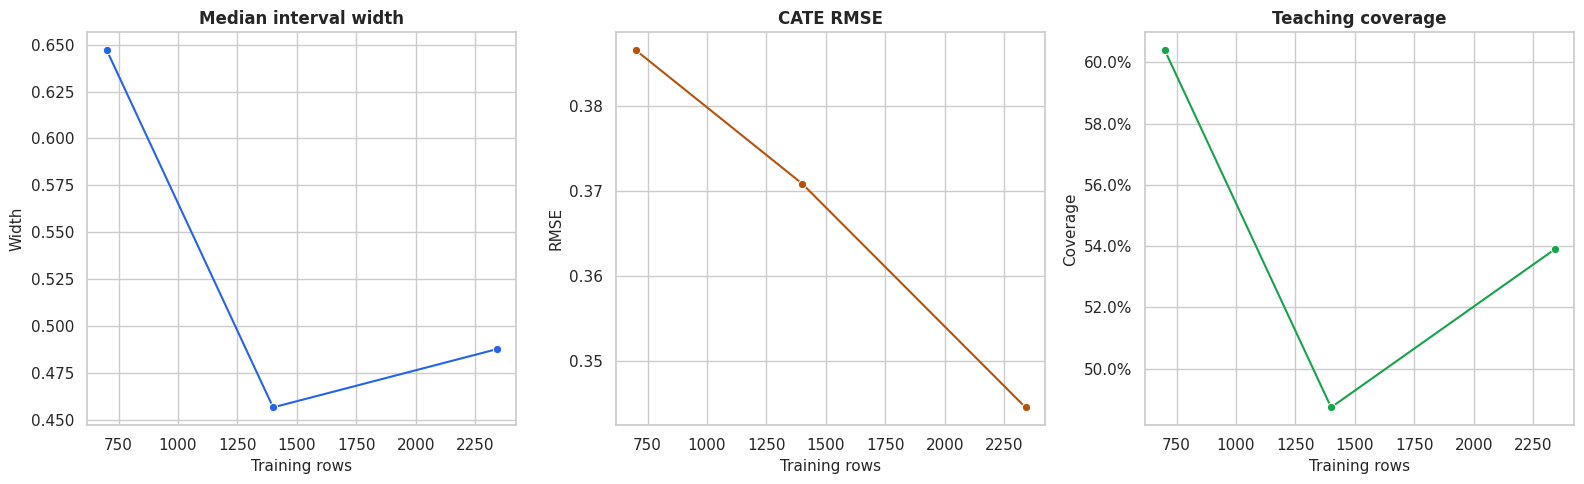

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

sns.lineplot(data=sample_size_sensitivity, x="training_rows", y="median_interval_width", marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("Median interval width")
axes[0].set_ylabel("Width")

sns.lineplot(data=sample_size_sensitivity, x="training_rows", y="cate_rmse", marker="o", ax=axes[1], color="#b45309")
axes[1].set_title("CATE RMSE")
axes[1].set_ylabel("RMSE")

sns.lineplot(data=sample_size_sensitivity, x="training_rows", y="row_level_coverage", marker="o", ax=axes[2], color="#16a34a")
axes[2].set_title("Teaching coverage")
axes[2].set_ylabel("Coverage")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))

for ax in axes:
    ax.set_xlabel("Training rows")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_sample_size_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The plot gives a concrete story for uncertainty: more data can improve precision, but the benefit depends on whether the additional data improves support in the right regions.

## Segment-Level Uncertainty

Segment summaries are easier to communicate than thousands of row-level intervals. Here we summarize estimates and interval widths by combinations of need and support risk. This is often how model results become actionable for non-technical stakeholders.

In [37]:
segment_df = eval_df.copy()
segment_df["need_segment"] = np.where(segment_df["baseline_need"] > segment_df["baseline_need"].median(), "higher need", "lower need")
segment_df["risk_segment"] = np.where(segment_df["support_risk"] == 1, "support risk", "regular support")

segment_uncertainty = (
    segment_df.groupby(["need_segment", "risk_segment"], observed=True)
    .agg(
        rows=("forest_cate", "size"),
        mean_estimated_cate=("forest_cate", "mean"),
        mean_true_cate=("true_cate", "mean"),
        mean_lower_95=("forest_lower_95", "mean"),
        mean_upper_95=("forest_upper_95", "mean"),
        median_interval_width=("forest_interval_width", "median"),
        share_lower_bound_above_zero=("forest_lower_95", lambda s: np.mean(s > 0)),
        treatment_rate=("treatment", "mean"),
    )
    .reset_index()
)

segment_uncertainty.to_csv(TABLE_DIR / "09_segment_uncertainty_summary.csv", index=False)
display(segment_uncertainty)

,need_segment,risk_segment,rows,mean_estimated_cate,mean_true_cate,mean_lower_95,mean_upper_95,median_interval_width,share_lower_bound_above_zero,treatment_rate
0,higher need,regular support,466,0.528946,0.616764,0.330846,0.727046,0.388139,0.980687,0.545064
1,higher need,support risk,164,0.186550,0.176143,-0.142877,0.515977,0.656951,0.292683,0.731707
2,lower need,regular support,468,0.241847,-0.009781,0.043459,0.440235,0.382534,0.611111,0.309829
3,lower need,support risk,162,-0.038140,-0.423269,-0.292518,0.216238,0.504646,0.006173,0.456790


The segment summary shows which groups look promising and which groups remain uncertain. This is usually more reportable than a list of individual predictions.

## Plot Segment Uncertainty

This plot compares mean estimated CATE and interval bounds by segment. It keeps the segment view compact while still showing the uncertainty around each group.

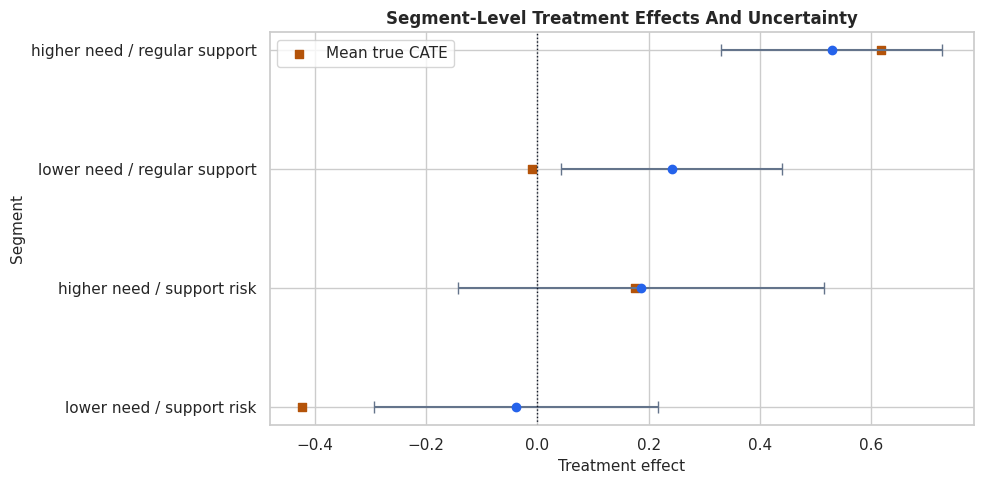

In [38]:
segment_plot = segment_uncertainty.copy()
segment_plot["segment"] = segment_plot["need_segment"] + " / " + segment_plot["risk_segment"]
segment_plot = segment_plot.sort_values("mean_estimated_cate")

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=segment_plot["mean_estimated_cate"],
    y=segment_plot["segment"],
    xerr=[
        segment_plot["mean_estimated_cate"] - segment_plot["mean_lower_95"],
        segment_plot["mean_upper_95"] - segment_plot["mean_estimated_cate"],
    ],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.scatter(segment_plot["mean_true_cate"], segment_plot["segment"], marker="s", color="#b45309", label="Mean true CATE")
ax.axvline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Segment-Level Treatment Effects And Uncertainty")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("Segment")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_segment_uncertainty_summary.png", dpi=160, bbox_inches="tight")
plt.show()

The segment plot is a good final artifact for decision-makers. It shows both direction and precision, and it avoids pretending that all segments are equally well supported.

## Reporting Checklist

The final table turns the notebook into a reusable checklist. A credible uncertainty report should state the estimand, interval method, overlap issues, decision rule, and limitations in plain language.

In [39]:
reporting_checklist = pd.DataFrame(
    [
        {
            "item": "Estimand",
            "what_to_report": "State whether the main target is ATE, CATE, or policy value.",
            "why_it_matters": "Different estimands have different uncertainty behavior.",
        },
        {
            "item": "Interval method",
            "what_to_report": "Name the estimator and interval construction used by the analysis.",
            "why_it_matters": "Readers need to know what uncertainty source is represented.",
        },
        {
            "item": "Overlap",
            "what_to_report": "Show treatment overlap and where interval width is largest.",
            "why_it_matters": "Weak support can make CATE estimates fragile.",
        },
        {
            "item": "CATE calibration",
            "what_to_report": "Compare estimated CATE groups and uncertainty summaries.",
            "why_it_matters": "Ranking quality matters more than a single global metric for targeting.",
        },
        {
            "item": "Decision rule",
            "what_to_report": "Explain whether treatment is assigned by point estimate, lower bound, or cost threshold.",
            "why_it_matters": "The rule determines how uncertainty affects action.",
        },
        {
            "item": "Policy uncertainty",
            "what_to_report": "Report uncertainty around average selected-group value where possible.",
            "why_it_matters": "Stakeholders usually care about the policy, not only row-level estimates.",
        },
        {
            "item": "Limits",
            "what_to_report": "State that intervals do not repair omitted confounding, leakage, or bad treatment definitions.",
            "why_it_matters": "Statistical precision is not the same as causal validity.",
        },
    ]
)

reporting_checklist.to_csv(TABLE_DIR / "09_uncertainty_reporting_checklist.csv", index=False)
display(reporting_checklist)

,item,what_to_report,why_it_matters
0,Estimand,"State whether the main target is ATE, CATE, or...",Different estimands have different uncertainty...
1,Interval method,Name the estimator and interval construction u...,Readers need to know what uncertainty source i...
2,Overlap,Show treatment overlap and where interval widt...,Weak support can make CATE estimates fragile.
3,CATE calibration,Compare estimated CATE groups and uncertainty ...,Ranking quality matters more than a single glo...
4,Decision rule,Explain whether treatment is assigned by point...,The rule determines how uncertainty affects ac...
5,Policy uncertainty,Report uncertainty around average selected-gro...,"Stakeholders usually care about the policy, no..."
6,Limits,State that intervals do not repair omitted con...,Statistical precision is not the same as causa...


The checklist is deliberately practical. It encourages a report that explains what can be trusted, what is uncertain, and what uncertainty does to the final decision.

## Summary

This notebook showed how to move from treatment-effect estimates to uncertainty-aware causal decisions.

The main lessons are:

- ATE intervals and CATE intervals answer different questions.
- Row-level CATE intervals are often much wider than average-effect intervals.
- Weak overlap and noisy segments often explain where intervals are widest.
- Ranking by point estimate alone can select fragile high-uncertainty rows.
- Lower-confidence-bound targeting is a simple way to trade volume for confidence.
- Policy-value intervals help communicate the uncertainty around a decision rule.
- Confidence intervals do not validate the causal assumptions by themselves; they quantify estimation uncertainty under the model and design.

The next tutorial extends the treatment setup beyond binary treatment and introduces multiple-treatment and continuous-treatment examples.